# JEPA latent model — evaluation

Companion notebook for the decoder-free model in `src/jepa_control/`. Because there is
no decoder, nothing here scores pixel reconstruction. The latent is judged on three
questions instead:

1. **Did it avoid collapse?** VICReg is the only thing preventing it, so the variance /
   covariance terms and the participation ratio are load-bearing, not decoration.
2. **Is it interpretable?** A post-hoc linear readout `z -> macrostates` replaces the
   decoder. Its held-out R² is what licenses writing the MPC cost in readout space.
3. **Can you steer it?** Dose/step response, then genuine closed-loop MPC against the
   true ABM.

The default predictor is **linear** (`z' = A z + B u + c`). The post-hoc least-squares
operator `ls_linear` is then an optimality check: the trained `A`/`B` should match it.
For the `--predictor residual_mlp` ablation, the same gap instead measures what the
nonlinearity is buying.

In [1]:
from pathlib import Path

from koopman_control.paths import dataset_path, output_root

# These respect KOOPMAN_DATA_ROOT / KOOPMAN_OUTPUT_ROOT.
DATASET = dataset_path()
OUTPUT_ROOT = output_root()

# Point this at a run produced by `python -m jepa_control.train`.
RUN_DIR = Path(OUTPUT_ROOT / "jepa_training/jepa-ema-h10-d8")

checkpoints = sorted((RUN_DIR / "checkpoints").glob("best-*.ckpt"))
if not checkpoints:
    raise FileNotFoundError(f"No best-*.ckpt under {RUN_DIR / 'checkpoints'}")
CKPT = max(checkpoints, key=lambda p: p.stat().st_mtime)
METRICS = RUN_DIR / "logs/metrics.csv"
if not METRICS.exists():
    raise FileNotFoundError(f"Metrics not found: {METRICS}")

# Horizon at which the scorecard is scored. Matching the training horizon keeps
# these numbers comparable to the logged metrics.
SCORE_HORIZON = 16
# Runs used to fit the readout and probes. The full train split is ~500 MB resident.
N_PROBE_TRAIN = 40

print("dataset    :", DATASET)
print("checkpoint :", CKPT)
print("metrics    :", METRICS)

dataset    : /Users/jacobevarts/BagheriLab/abm-control/data/rabbit_grass_images/dataset.h5
checkpoint : /Users/jacobevarts/BagheriLab/abm-control/outputs/jepa_training/jepa-ema-h10-d8/checkpoints/best-000-1754-0.030330.ckpt
metrics    : /Users/jacobevarts/BagheriLab/abm-control/outputs/jepa_training/jepa-ema-h10-d8/logs/metrics.csv


## 1. Load and score

One cell does all the expensive work (encoding the held-out splits, fitting the readout
and probes, sweeping the simulator for dose-response) so every plot below is instant.

The readout is fit on **train** encodings and scored on **val**, so every R² quoted
later is held-out. That matters here more than usual: the encoder never saw the
observables during training, so this is a genuine test of what self-supervision
discovered rather than something the loss was pointed at.

In [2]:
%matplotlib inline
import numpy as np

from jepa_control import evaluate as ev
from jepa_control import plots as jp

model = ev.load_model(CKPT)
val = ev.load_split_trajectories(DATASET, "val")
test = ev.load_split_trajectories(DATASET, "test")
probe_train = ev.load_split_trajectories(DATASET, "train", N_PROBE_TRAIN)

# Encode once, reuse everywhere.
enc = ev.encode_all(model, val)
enc_train = ev.encode_all(model, probe_train)

# The readout is the decoder's replacement: fit on train, scored on held-out val.
readout = ev.fit_readout(enc_train)
r2_val = ev.readout_r2(readout, enc)

fitted = ev.fit_latent_linear(model, enc)  # linearity diagnostic only
herr = ev.horizon_errors(model, enc, fitted)
pca = ev.latent_pca(enc)
probe = ev.linear_probe(model, probe_train, val)
skill = ev.readout_rollout_skill(model, enc, readout)
dose = ev.dose_response(model, readout, steps=100, seeds=(0, 1, 2))

print(f"latent dim    : {model.latent_dim}   train horizon: {model.hparams.horizon}")
print(f"readout loss  : w_readout={model.hparams.w_readout} "
      f"({'anchored' if model.hparams.w_readout > 0 else 'pure JEPA'})")
print(f"held-out runs : {len(val)} val / {len(test)} test, {enc['z'].shape[1]} frames each")
print()
print(ev.format_scorecard(ev.scorecard(
    model=model, herr=herr, probe=probe, pca=pca, readout_r2_test=r2_val,
    rollout_skill=skill, dose=dose, fitted=fitted, horizon=SCORE_HORIZON,
)))

latent dim    : 8   train horizon: 10
readout loss  : w_readout=0.0 (pure JEPA)
held-out runs : 84 val / 42 test, 201 frames each

metric                                 value  status  note
--------------------------------------------------------------
prediction skill @ h=16               +0.475  [warn]  vs +0.015 for the persistence baseline
beats persistence?                       yes  [ ok ]  a model that loses to a frozen latent learned no dynamics
no collapse (dims in use)            2.9 / 8  [warn]  participation ratio; 3 components cover 95%
rabbit_count readout R^2              +0.973  [ ok ]  held-out; this is what the MPC cost is written in
control legible in latent             +0.336  [warn]  R^2 predicting the applied u from z alone
macrostate rollout corr               -0.261  [FAIL]  free-running; RMSE 120.9
dose-response monotonic                +1.00  [FAIL]  -1 means more culling reliably predicts fewer rabbits
ls_linear skill (diagnostic)          +0.442  [ -- ]  pos

## 2. What control does the data actually contain?

Identifiability is a property of the *data*, not the model: the actuator can only be
learned at amplitudes and rates the trajectories visit. Unchanged from the sibling
pipeline, since this branch reuses the same dataset.

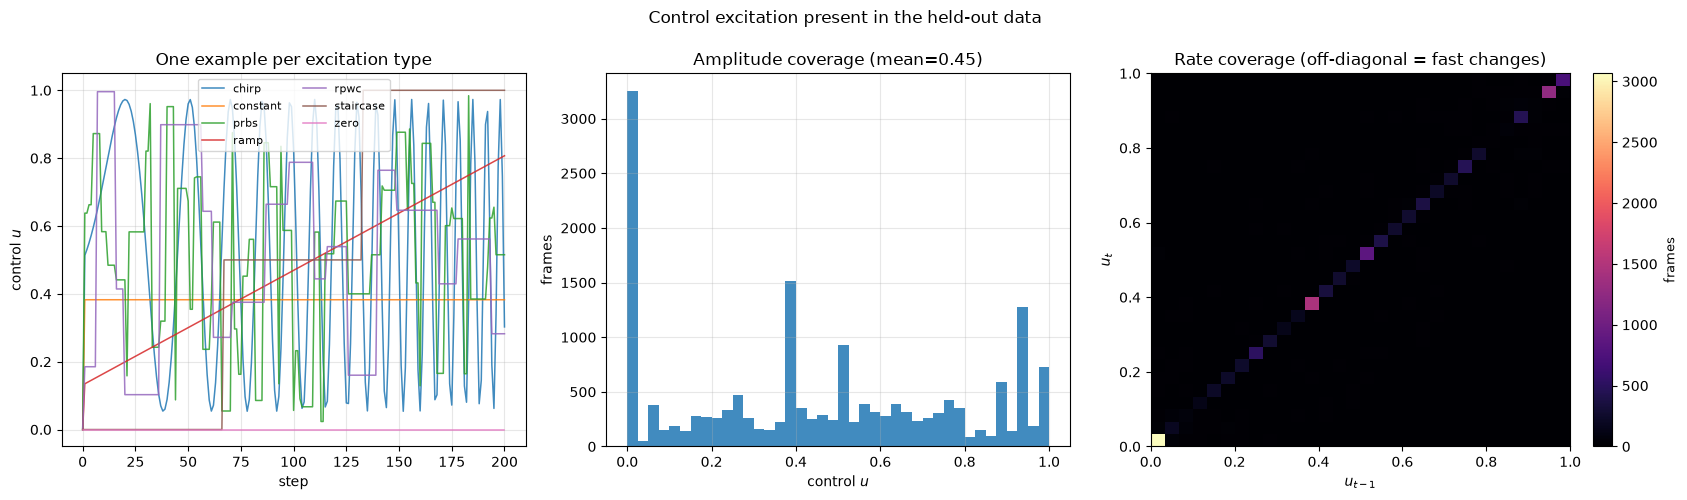

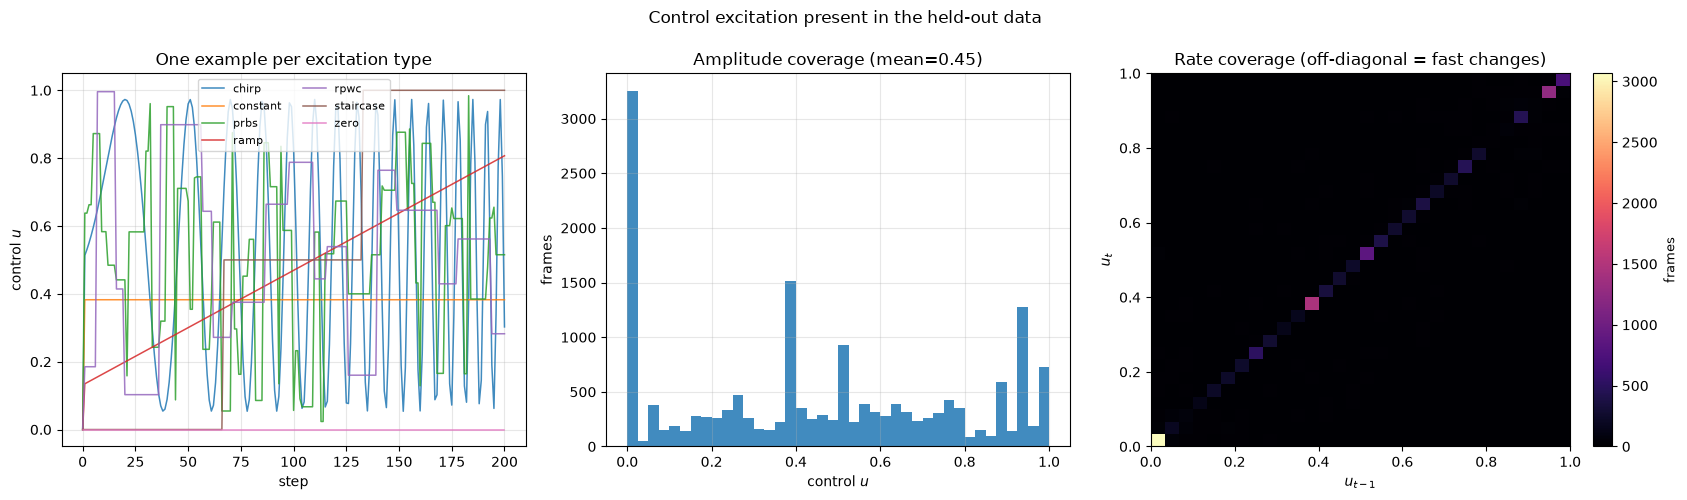

In [3]:
jp.fig_control_coverage(val)

## 3. Training curves

The middle panel is the one unique to this model. `vic_var` near 0 means every latent
dimension sits above the variance floor; if it climbs toward 1 the representation is
collapsing. The participation ratio on the right is the subtler check — it catches a
latent quietly shrinking into a low-dimensional subspace while the loss still improves.

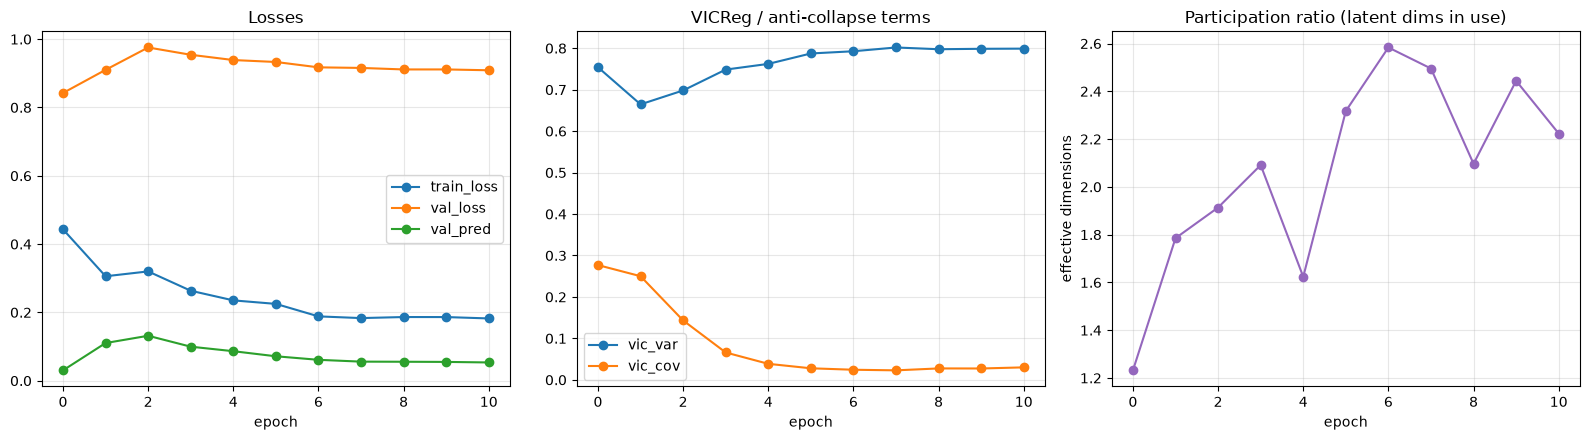

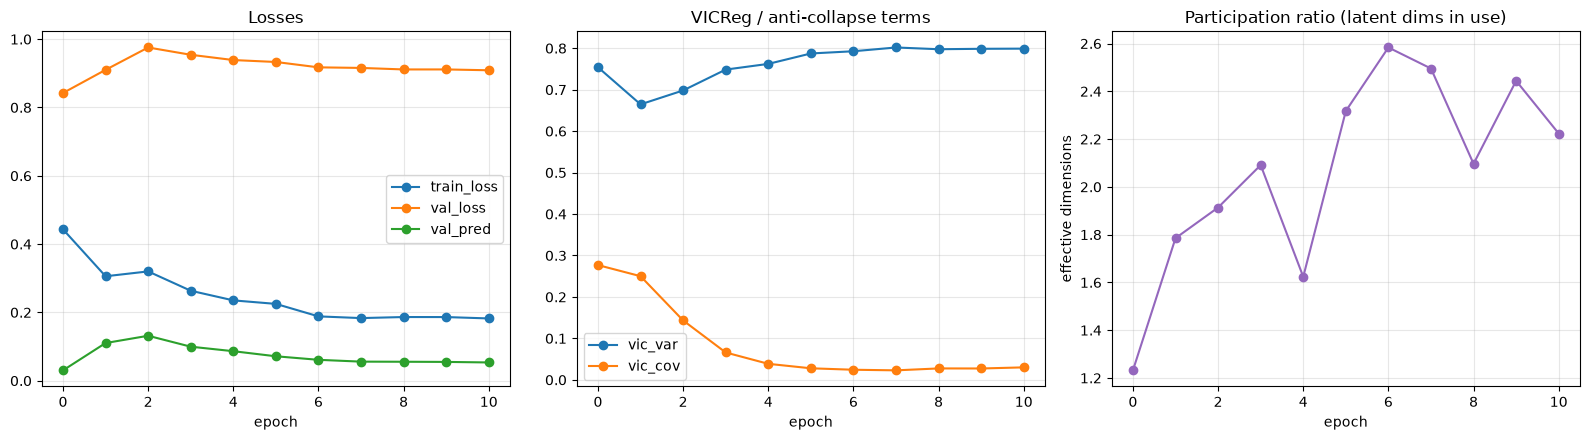

In [4]:
jp.fig_learning_curves(METRICS)

## 4. Prediction accuracy, against baselines

`persistence` (freeze the initial latent) is the floor — losing to it means no dynamics
were learned. `ls_linear` is the best least-squares linear operator in this same latent.
With the default linear predictor, `full` should sit on top of `ls_linear`; a visible
gap means the trained `A`/`B` are under-optimized relative to what the latent supports.
For the `residual_mlp` ablation, that same gap instead measures what the nonlinearity
is buying.

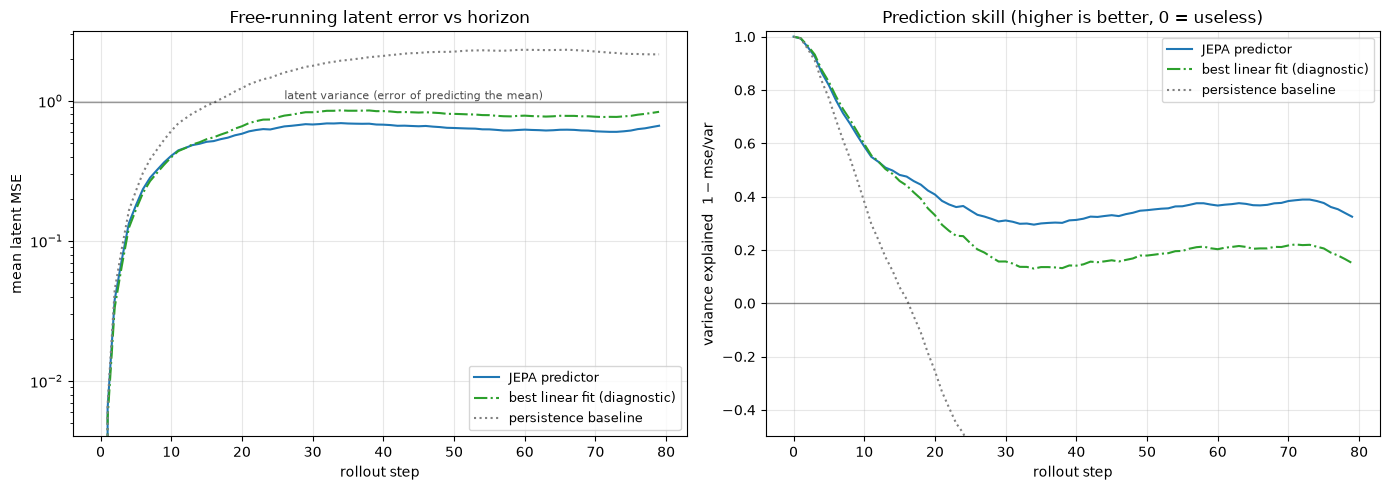

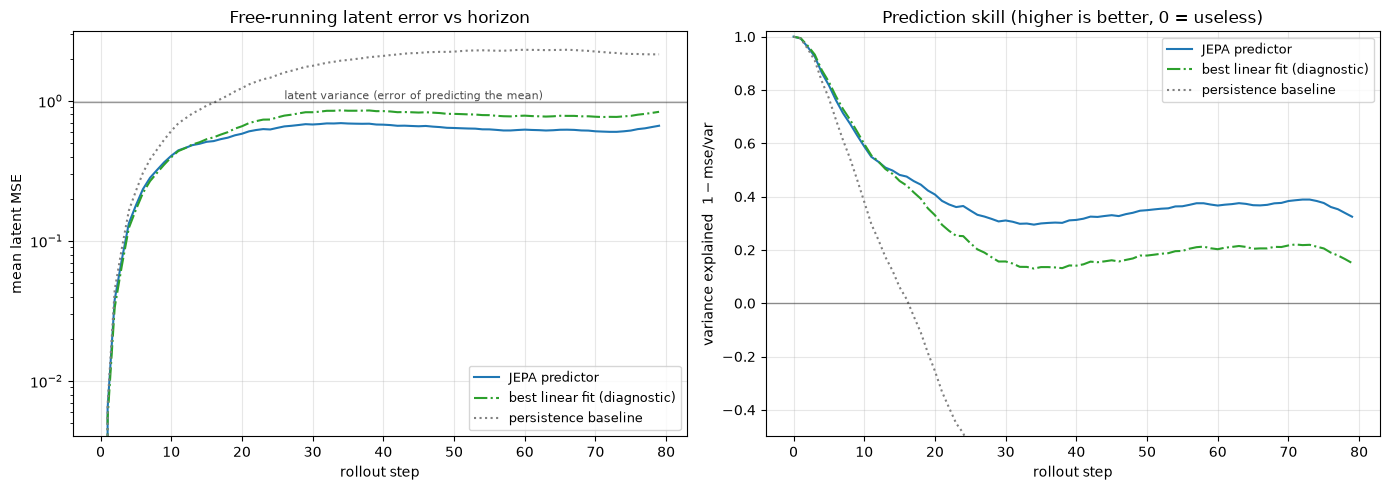

In [5]:
jp.fig_horizon_errors(herr, max_step=80)

## 5. Is the latent uncollapsed and structured?

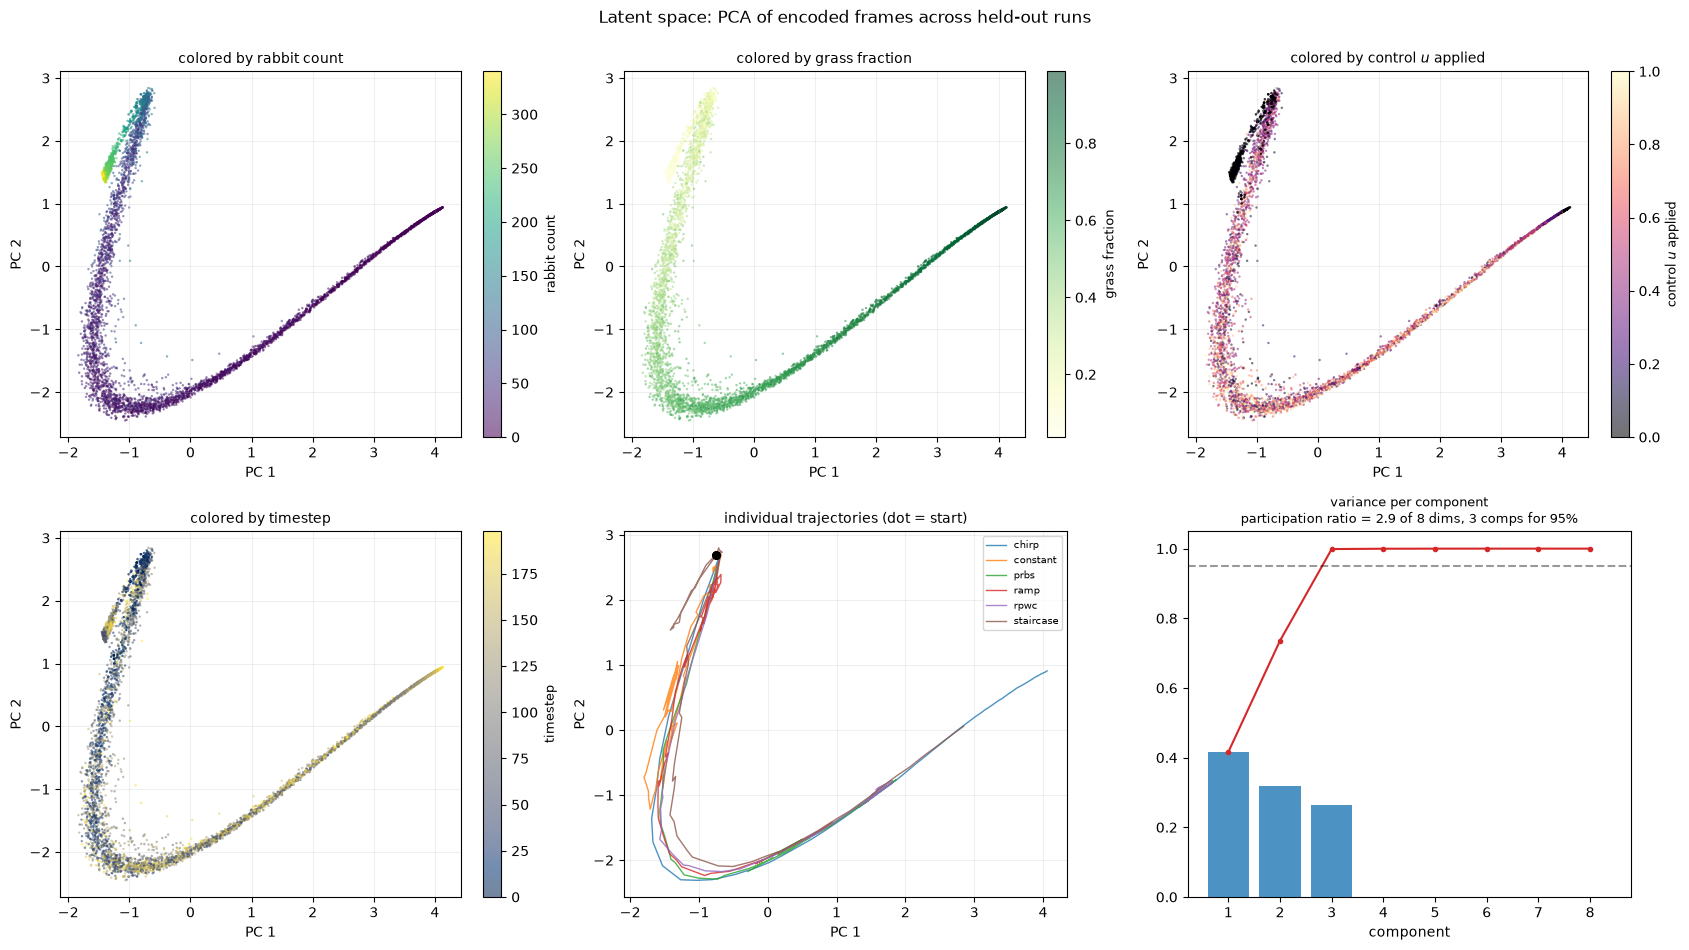

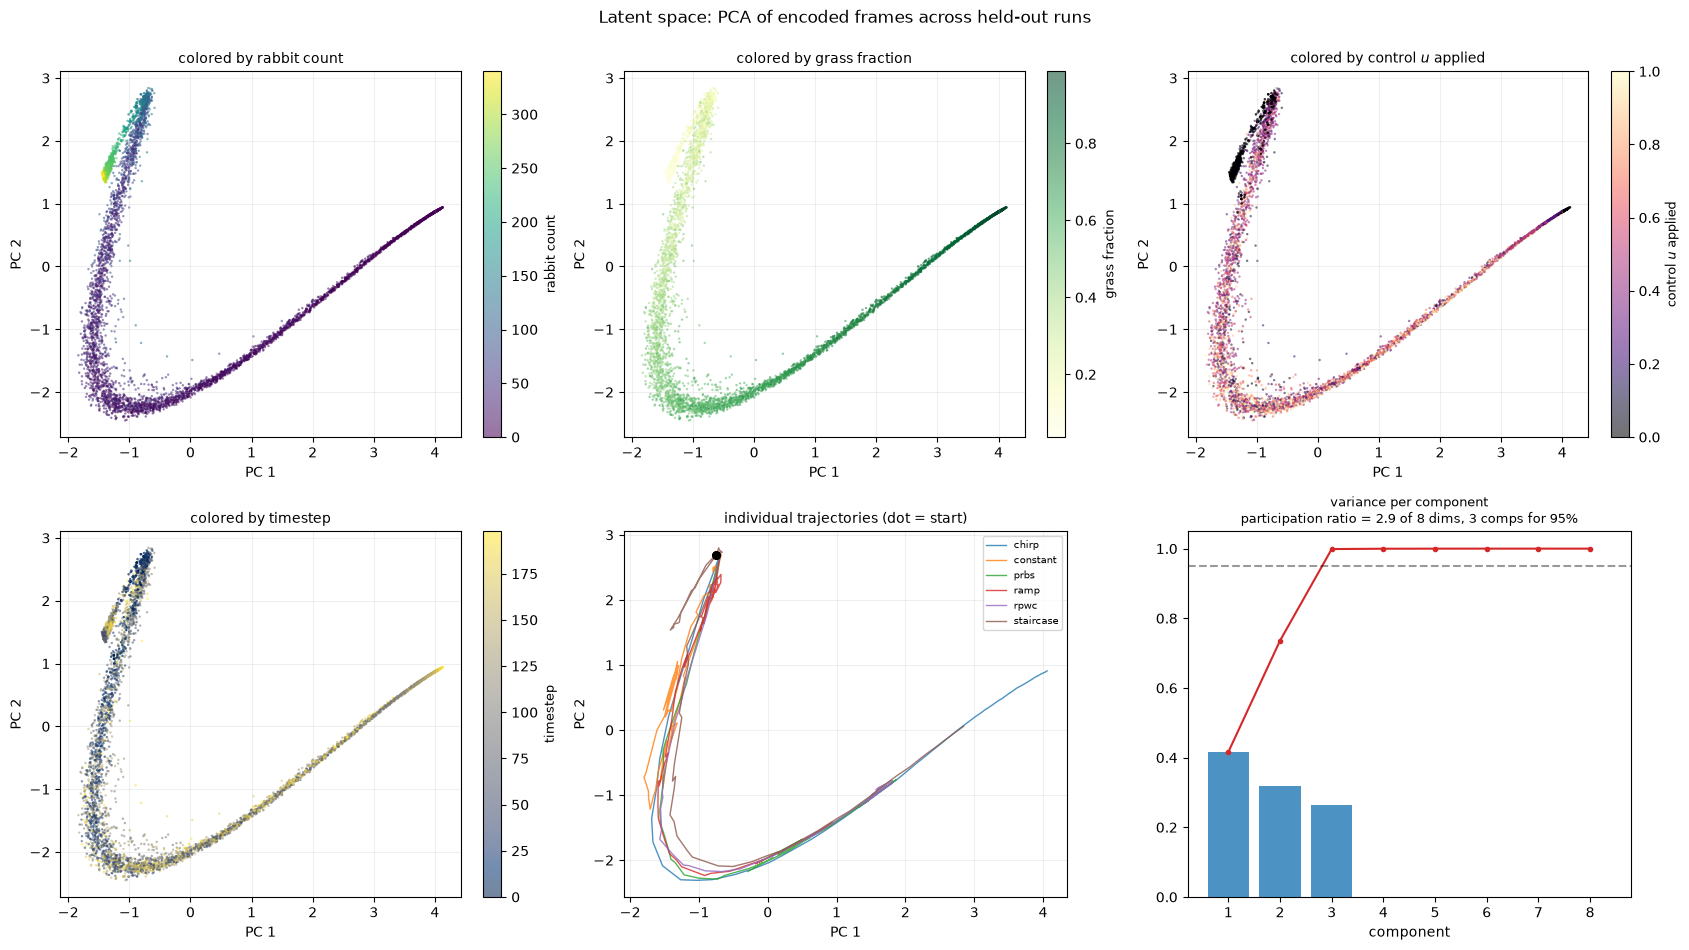

In [6]:
jp.fig_latent_pca(pca, stride=3, n_traj_lines=6)

### 5b. What can be linearly read out of the latent?

`rabbit_count` is the headline: the MPC cost is written in this quantity, so a weak R²
here caps everything downstream. `u_applied` is the collapse mode specific to control —
an encoder can look healthy on every other metric while having discarded the actuator's
signature entirely.

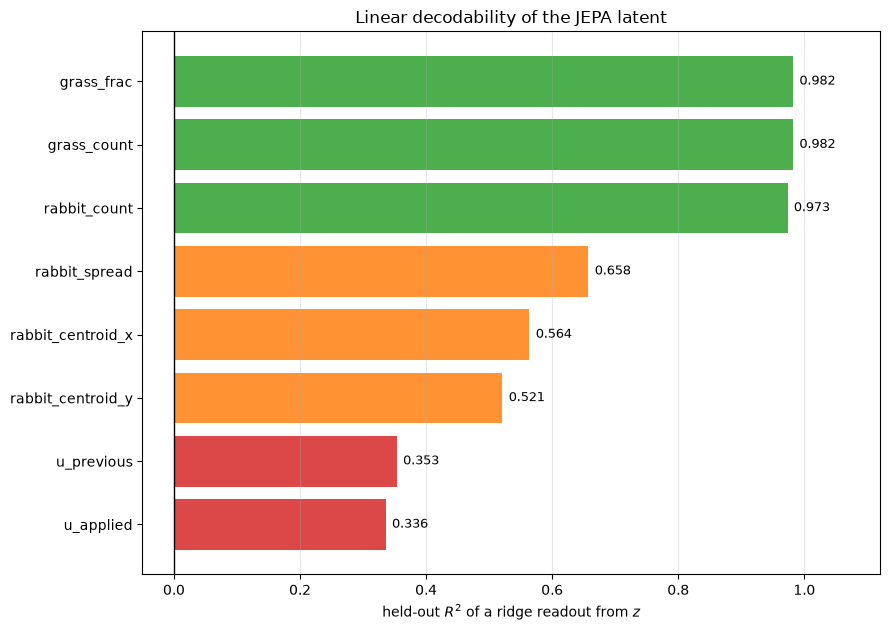

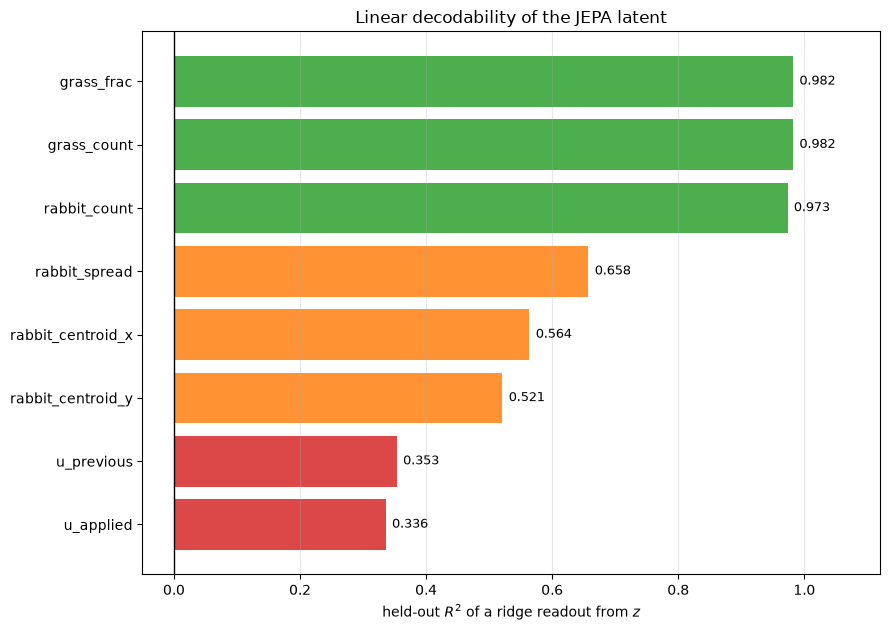

In [7]:
jp.fig_latent_probe(probe)

### 5c. Individual latent dimensions over time

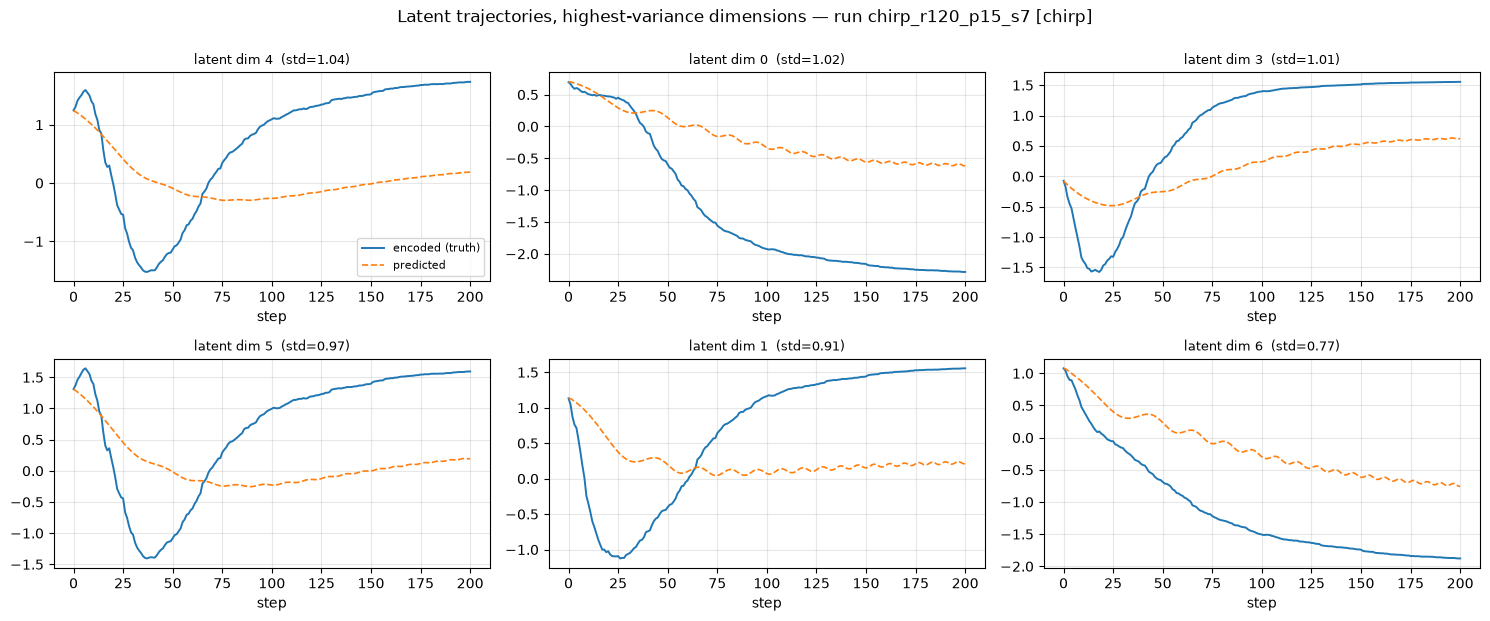

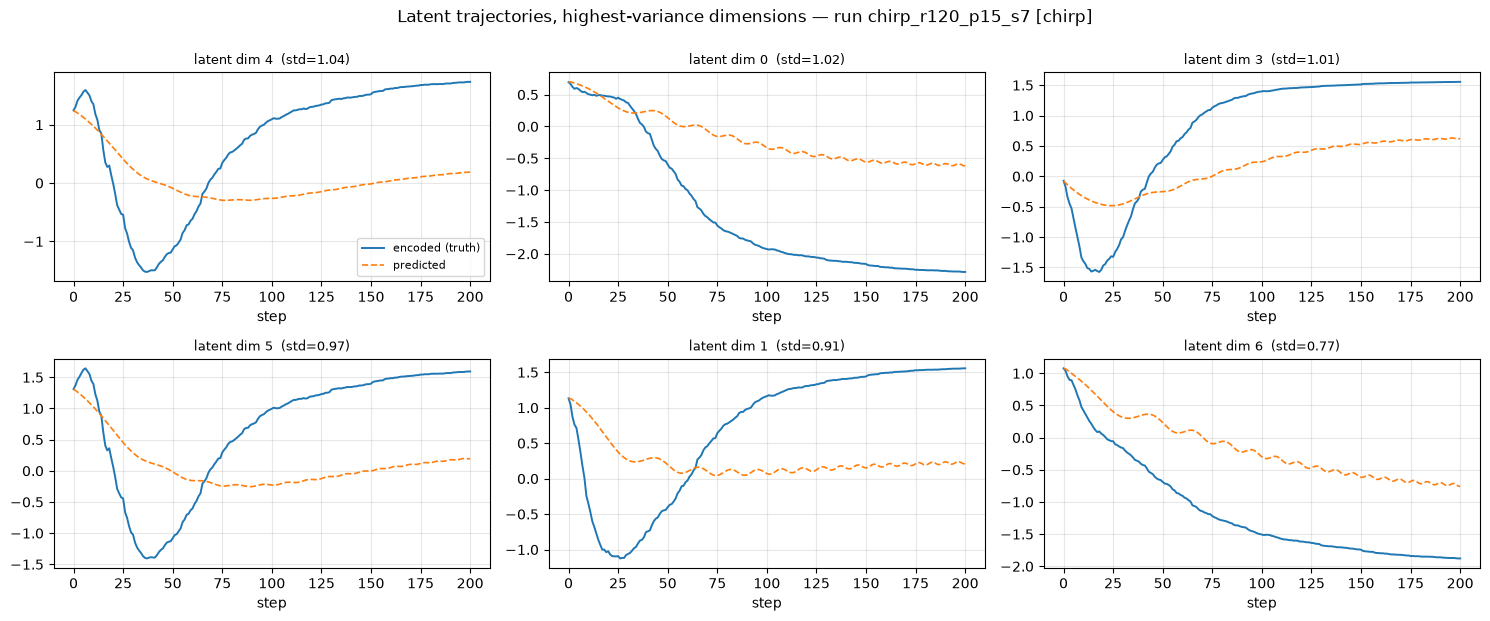

In [8]:
jp.fig_latent_traces(model, val[0], n_dims=6)

## 6. The readout — the decoder's replacement

Instead of asking whether pixels come back, ask whether the quantities you care about
are recoverable from `z` by a linear map. Points on the diagonal mean yes.

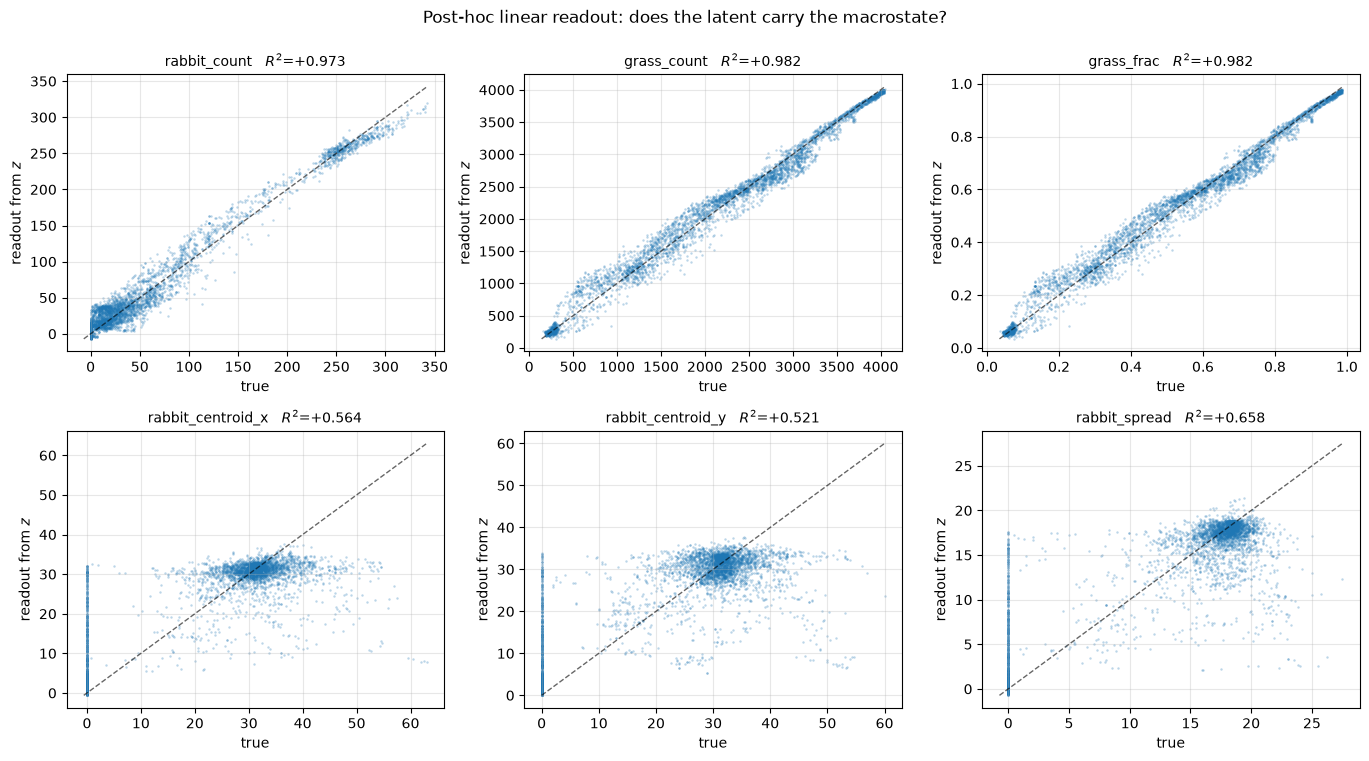

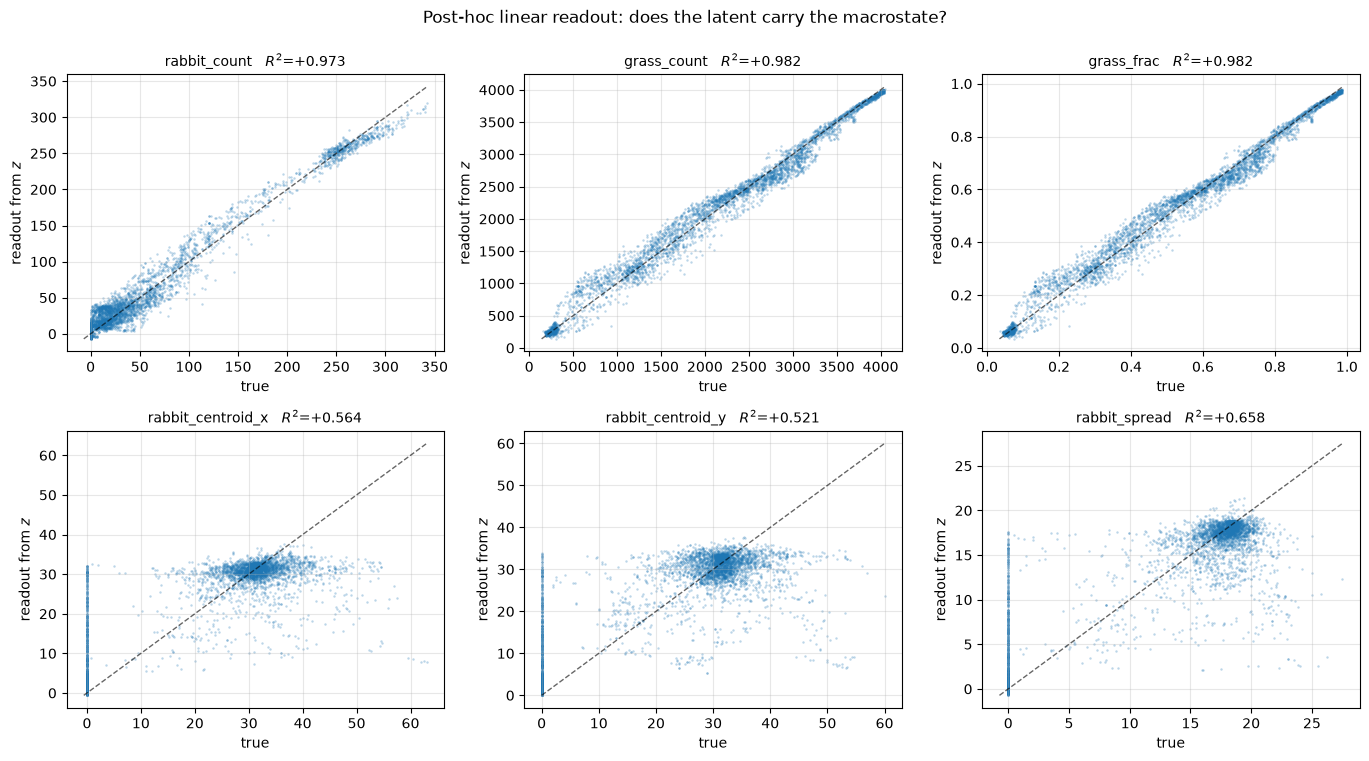

In [9]:
jp.fig_readout_quality(readout, enc, r2_val)

### 6b. Free-running macrostate

Only the first frame is observed; the rest is predicted from the control sequence alone
and mapped through the readout. This is what MPC will believe when it plans, so
systematic bias here becomes steady-state tracking error in section 8.

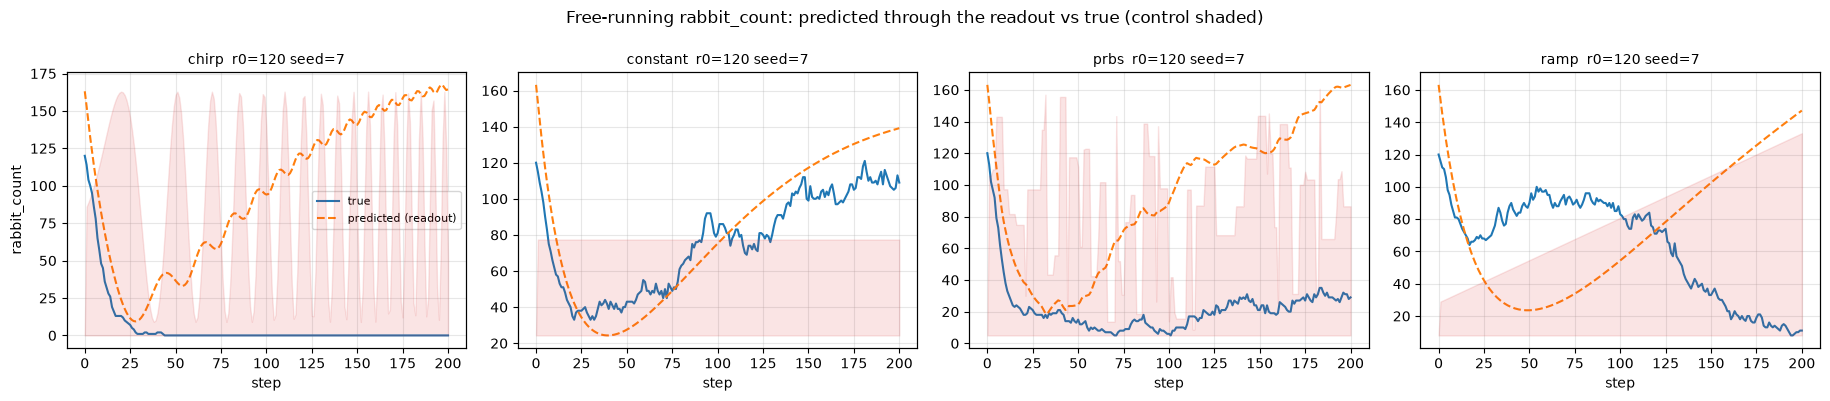

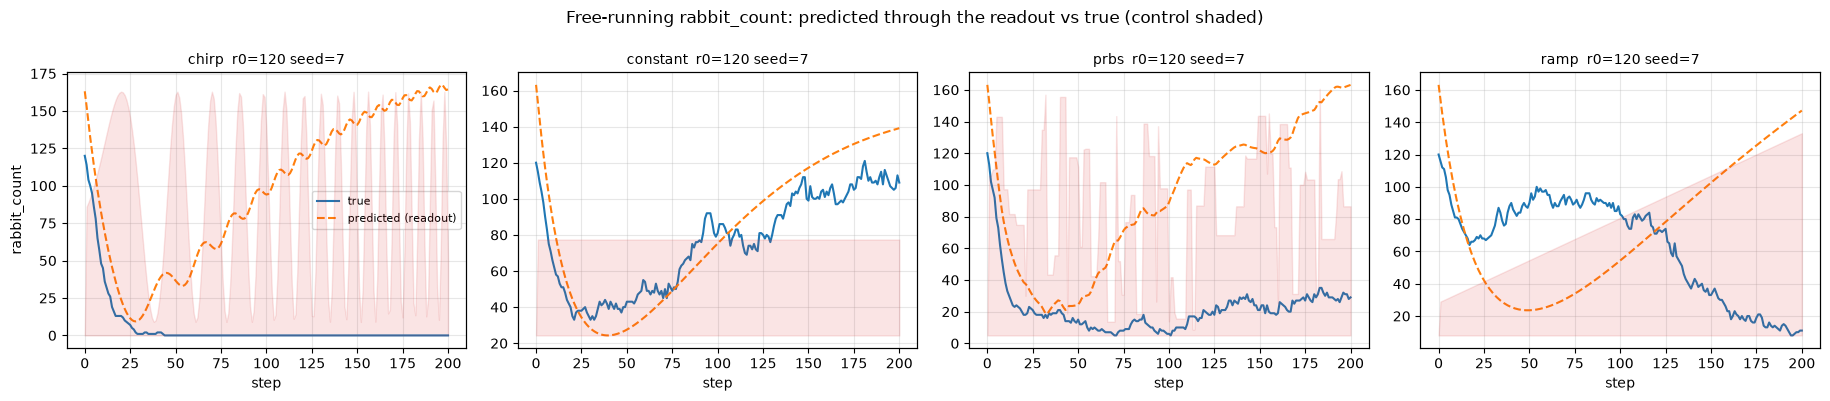

In [10]:
jp.fig_readout_rollout(model, val, readout, n=4)

## 7. Does the model understand the control?

Monotonicity is the requirement, not calibration. A planner survives wrong magnitudes;
it cannot survive a scrambled ordering.

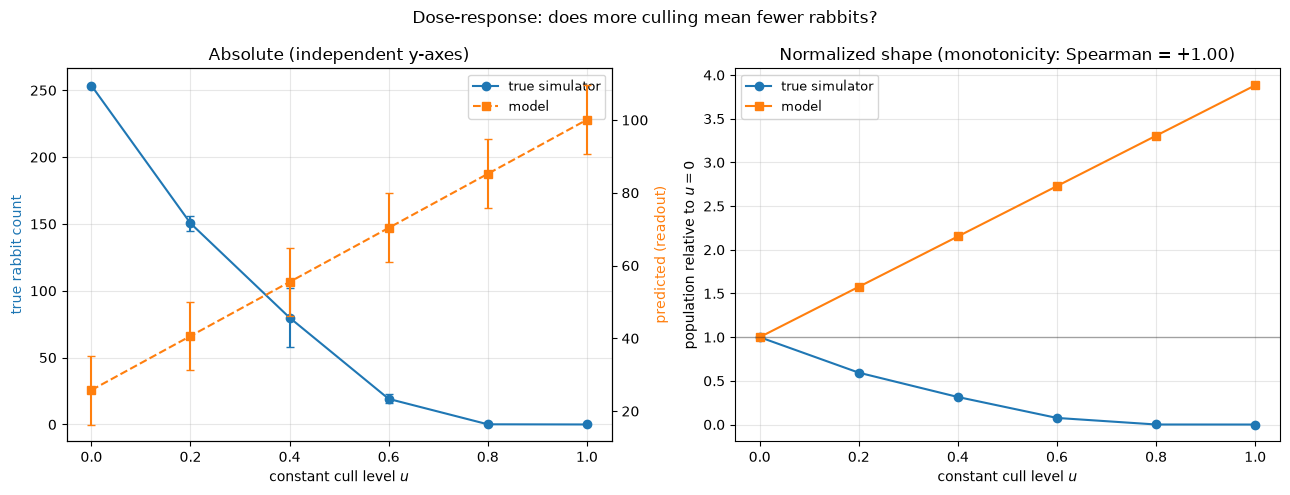

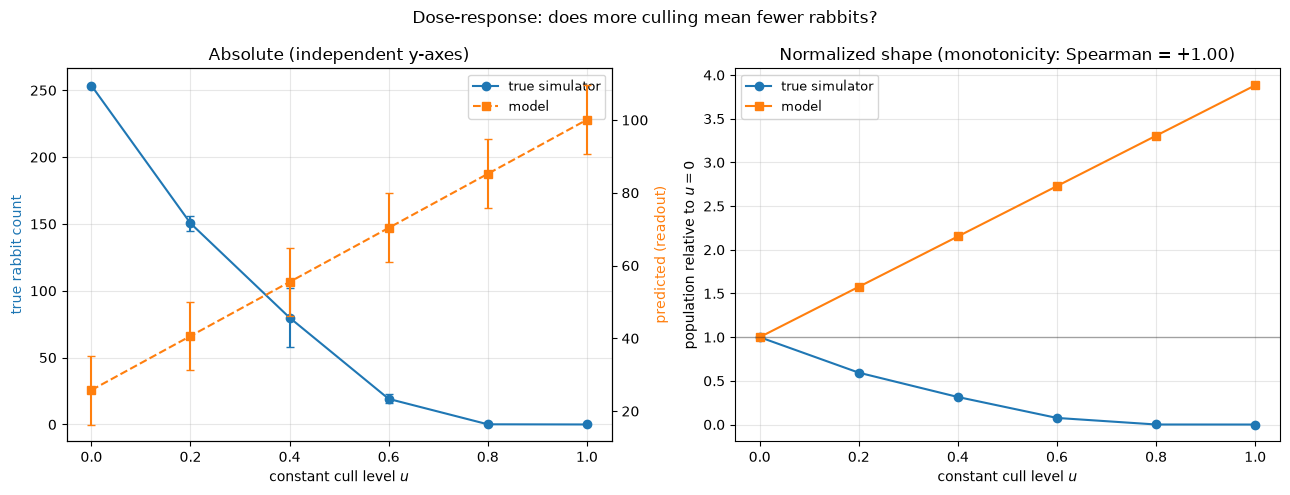

In [11]:
jp.fig_dose_response(dose)

### 7b. Step and impulse response

The settling time you read off here is the practical lower bound for `plan_horizon` in
the MPC config below — if the control's effect takes 30 steps to express itself, a
10-step planner is blind to most of it.

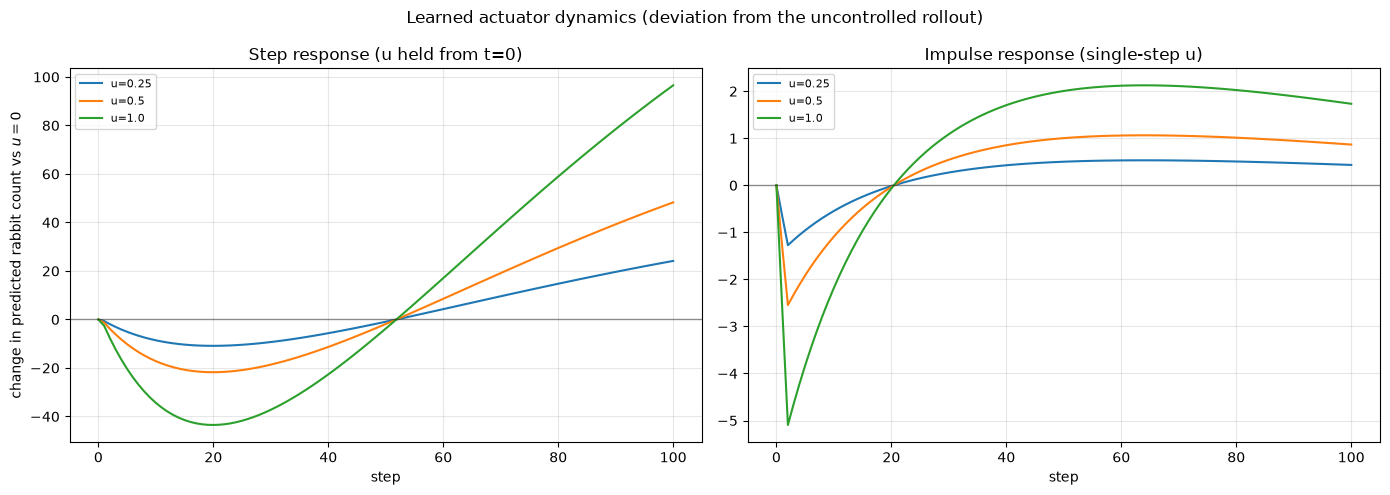

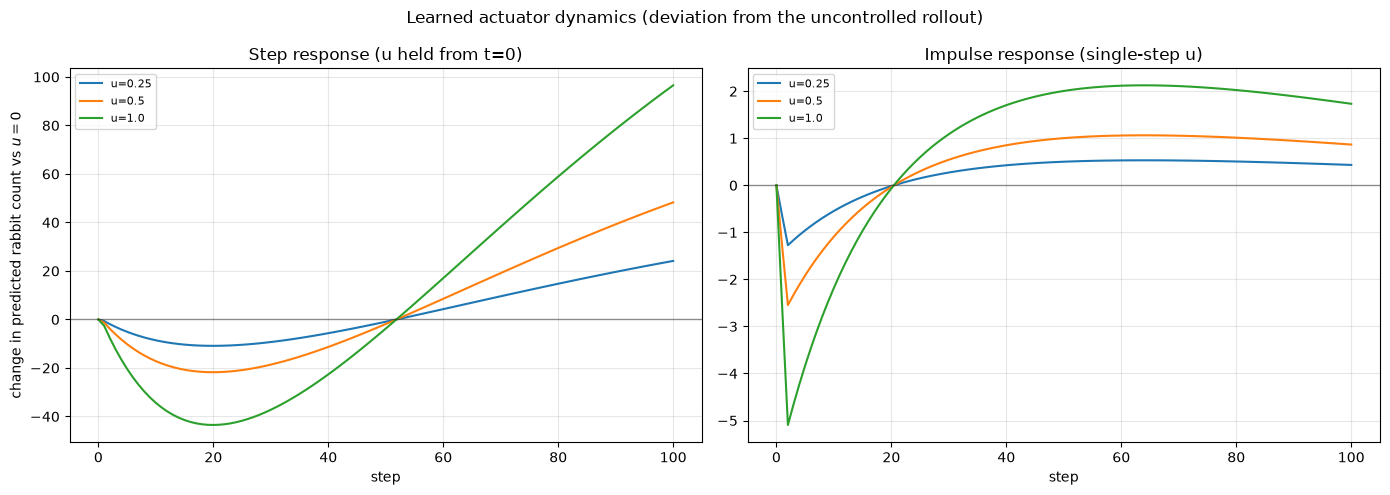

In [12]:
jp.fig_step_response(model, enc["z"][0, 0], readout, steps=100)

## 8. Closed-loop MPC against the true ABM

The actual point of the whole pipeline: encode the current frame, plan a control
sequence with CEM through the learned predictor, apply only the first action to the
**true simulator**, and repeat.

The target is set midway between the uncontrolled and maximum-cull endpoints so it is
reachable by construction — a target outside that band would just saturate the actuator
and tell you nothing. This cell is the slowest in the notebook (it replans at every
step); lower `MPC_STEPS` or `n_samples` if you are iterating.

uncontrolled end 305, full-cull end 0
target = 152 rabbits
tracking RMSE 22.5, final error +15.5


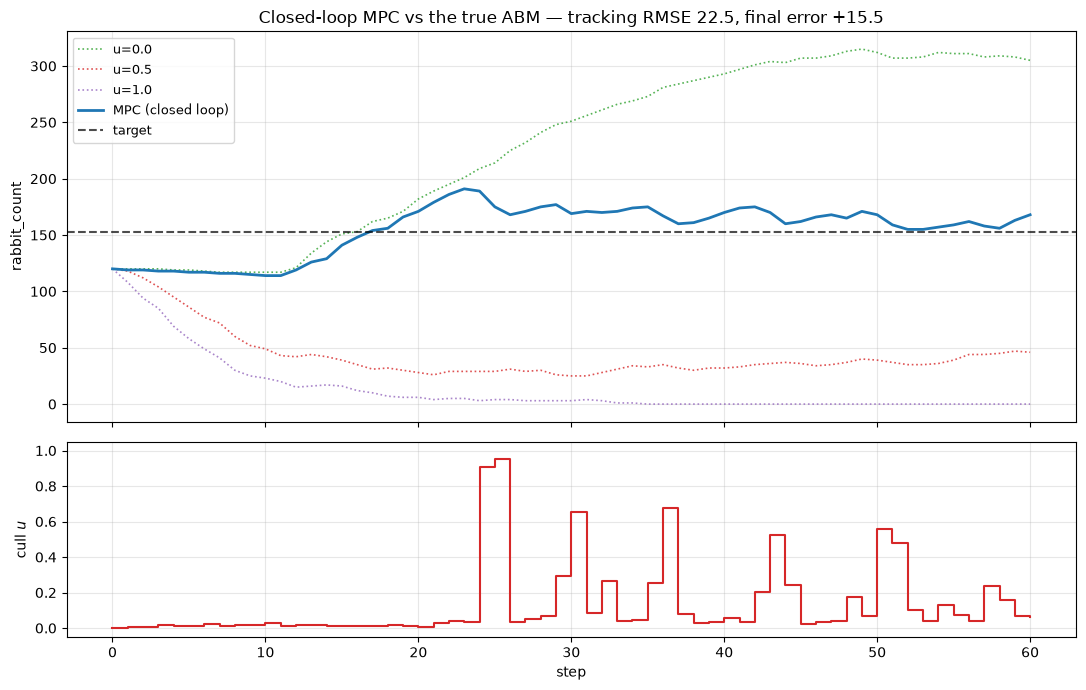

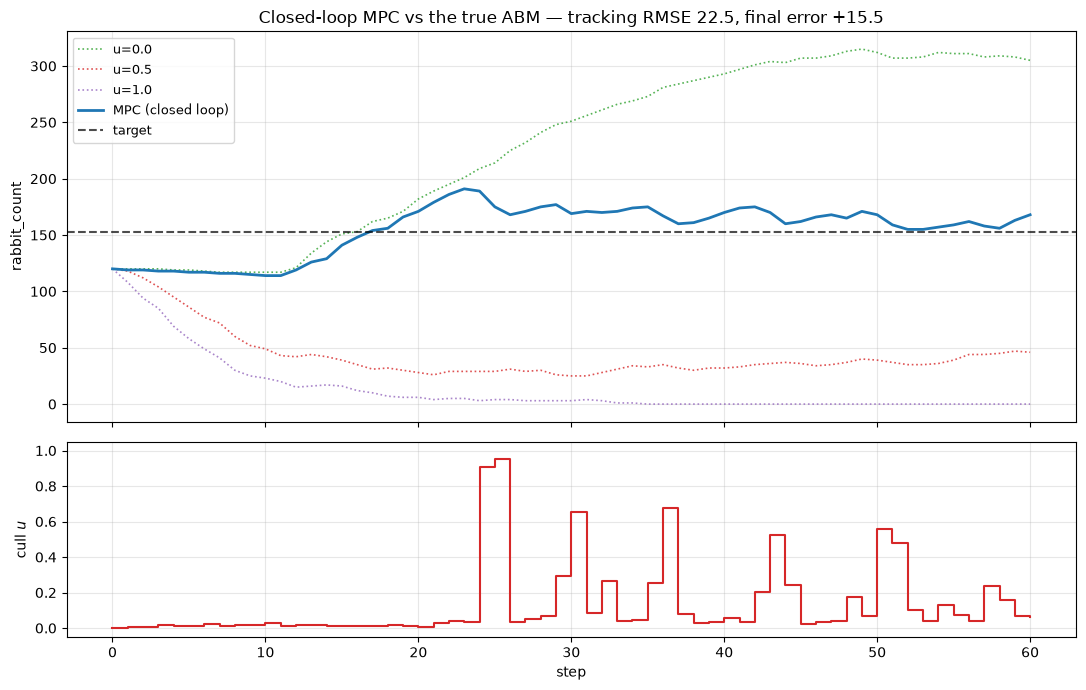

In [13]:
from jepa_control.control import MPCConfig, baseline_rollouts, closed_loop

MPC_STEPS = 60
INITIAL_RABBITS = 120

base = baseline_rollouts(
    steps=MPC_STEPS, levels=(0.0, 0.5, 1.0), initial_rabbits=INITIAL_RABBITS, seed=0
)
TARGET = float(0.5 * (base["u=0.0"][-1] + base["u=1.0"][-1]))
print(f"uncontrolled end {base['u=0.0'][-1]:.0f}, full-cull end {base['u=1.0'][-1]:.0f}")
print(f"target = {TARGET:.0f} rabbits")

loop = closed_loop(
    model,
    readout,
    TARGET,
    steps=MPC_STEPS,
    initial_rabbits=INITIAL_RABBITS,
    seed=0,
    mpc=MPCConfig(plan_horizon=15, n_samples=256, n_iters=4, control_cost=0.0),
)
print(f"tracking RMSE {loop['tracking_rmse']:.1f}, final error {loop['final_error']:+.1f}")
jp.fig_closed_loop(loop, base)

## 9. Held-out test split

Touched once, at the end. The readout is still the one fitted on train.

In [14]:
enc_test = ev.encode_all(model, test)
r2_test = ev.readout_r2(readout, enc_test)
herr_test = ev.horizon_errors(model, enc_test, ev.fit_latent_linear(model, enc_test))
skill_test = ev.readout_rollout_skill(model, enc_test, readout)

h = min(SCORE_HORIZON, len(herr_test["steps"]) - 1)
print(f"test prediction skill @ h={h} : {herr_test['skill_full'][h]:+.3f}")
print(f"test rabbit_count readout R^2 : {r2_test['rabbit_count']:+.3f}")
print(f"test macrostate rollout corr  : {skill_test['corr']:+.3f}")
print()
for name, value in r2_test.items():
    print(f"  {name:<20} {value:+.3f}")

test prediction skill @ h=16 : +0.405
test rabbit_count readout R^2 : +0.973
test macrostate rollout corr  : -0.278

  rabbit_count         +0.973
  grass_count          +0.986
  grass_frac           +0.986
  rabbit_centroid_x    +0.557
  rabbit_centroid_y    +0.527
  rabbit_spread        +0.627


## 10. Reading the result

A checklist for turning the plots above into a decision.

**Did it collapse?** Section 3 and the PCA panel in section 5. A participation ratio far
below the latent width, or a `vic_var` term drifting upward, means VICReg is losing.
The fix is to raise `--w-vic-var` / `--w-vic-cov` before touching anything else, because
every other metric is meaningless on a collapsed latent.

**Did it learn dynamics?** Section 4, JEPA predictor vs persistence. If the model does
not beat a frozen latent at your horizon of interest, nothing downstream matters.

**Is the latent worth controlling?** Sections 5b and 6. `rabbit_count` R² is the gate:
the MPC cost is written in that quantity, so a weak readout caps closed-loop
performance no matter how good the predictor is. This is the number that decides
whether to turn on the anchoring loss — retrain with `--w-readout 1.0` and compare.
That comparison is the pure-vs-anchored ablation, and it is worth reporting either way.

**Is the trained linear predictor optimal?** Section 4, JEPA predictor vs `ls_linear`.
With `predictor='linear'`, they should match; a gap is under-training, not evidence for
nonlinearity. If you retrain with `--predictor residual_mlp` and still cannot beat
`ls_linear`, the latent itself is effectively linear and LQR-style control applies.

**Can you steer it?** Sections 7 and 8. Monotonic dose-response is necessary but not
sufficient; the real test is beating the best constant-cull baseline in closed loop. If
MPC tracks poorly while open-loop prediction looks fine, suspect the planner before the
model: lengthen `plan_horizon` toward the settling time from 7b, raise `n_samples`, or
add a small `control_cost` to damp chattering.

**Does the latent earn its keep?** Section 11. A fitted rabbit/grass ODE with oracle
macros and the same CEM planner is the strong baseline. Matching or beating its
tracking RMSE is the bar for claiming the image→latent controller is useful; losing
badly means the representation / readout path is the bottleneck, not the planner.

**Where to push next.** Persistent steady-state offset with good correlation points at
readout bias rather than dynamics — refit the readout on a window matched to the control
regime you operate in. Good tracking here is the green light for phase 2 (spatial,
region-wise control), which needs a new dataset from the extended actuator.

## 11. Baseline: fit a resource ODE and control with it

The JEPA stack has to beat a much simpler alternative: ignore images entirely, fit a
discrete consumer-resource ODE on `(rabbit_count, grass_frac)`, and run the **same CEM
MPC** with that ODE as the planner.

$$
\begin{aligned}
R' &= R + R\,(\alpha G - \mu - \kappa u - \lambda u_{\mathrm{prev}}) \\
G' &= G + r(1-G) - \beta R G
\end{aligned}
$$

Parameters are fit by least squares on one-step deltas from the **train** split. Closed
loop still acts on the true ABM, but the ODE planner gets **oracle** macrostates each
step (not image → latent → readout) — so this is a strong baseline, not a weak strawman.
If JEPA cannot match or beat it on tracking RMSE under the same target / horizon /
seed as section 8, the latent controller is not yet earning its complexity.

fitted resource ODE
  growth=0.1428  death=0.0050  cull_now=0.1630  cull_lag=-0.0188
  regrow=0.0104  consume=0.000285
  one-step R²  rabbit ΔR/R=+0.096  grass ΔG=+0.402

val free-rollout @ h=16: ODE skill -0.450  (persistence -3.438)

ODE MPC  tracking RMSE 16.0, final error +4.5
JEPA MPC tracking RMSE 22.5, final error +15.5
JEPA − ODE RMSE: +6.5  (ODE better)


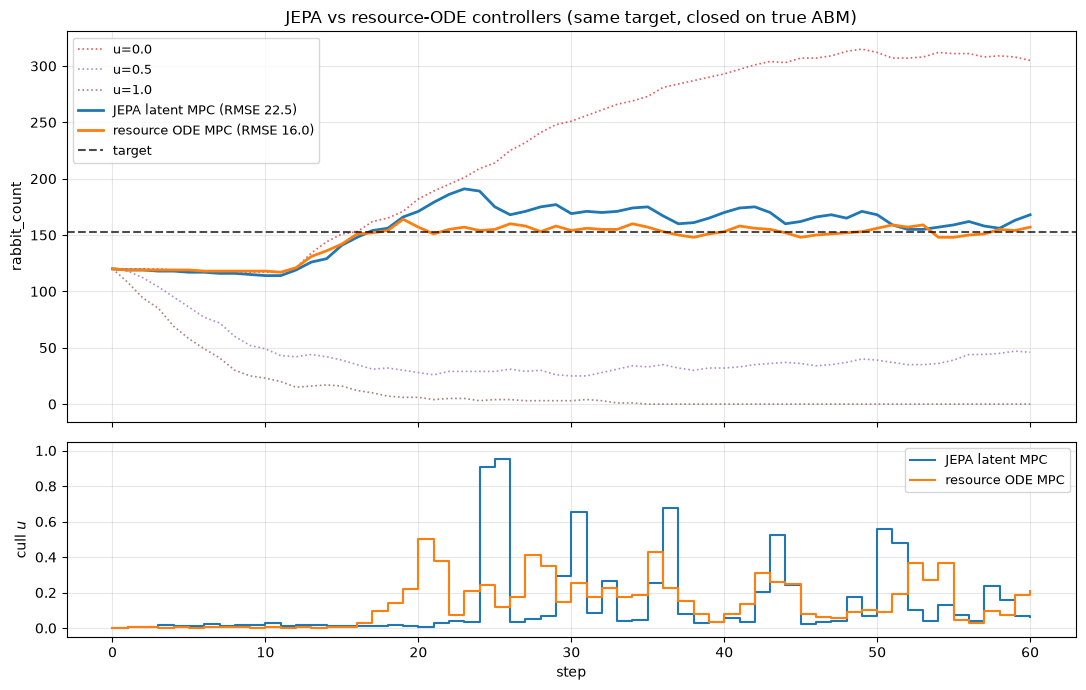

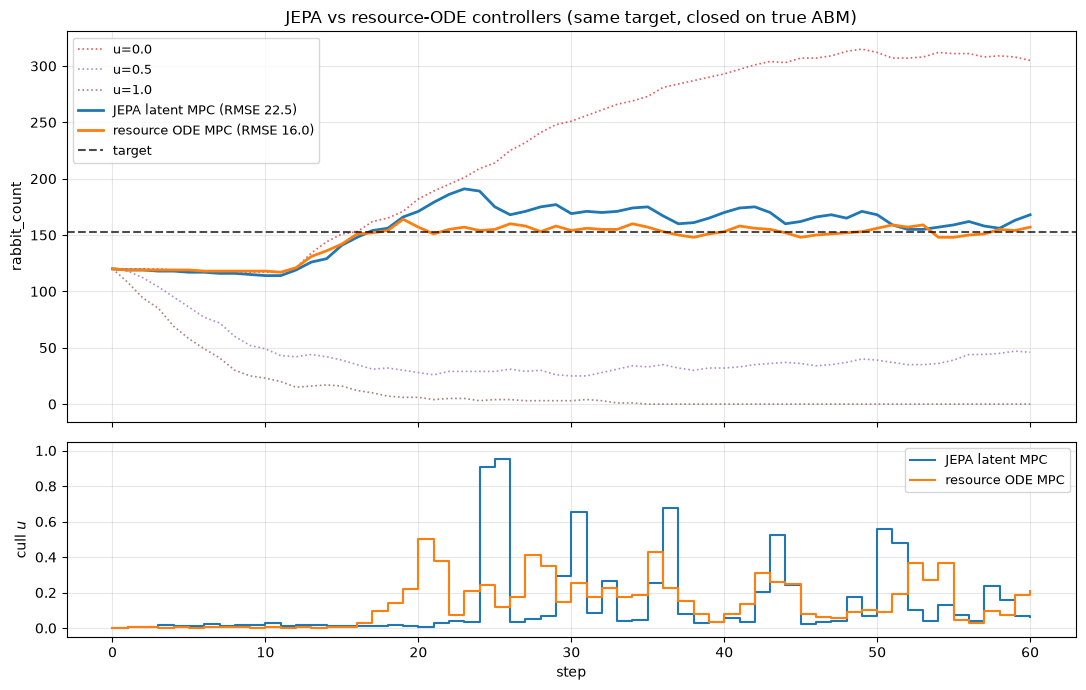

In [15]:
from jepa_control.ode_baseline import (
    closed_loop_ode,
    fit_resource_ode,
    ode_prediction_skill,
)
from jepa_control.plots import fig_controller_compare

# Fit on the same train probe set used for the readout (already loaded above).
# For a tighter baseline, swap in the full train split.
ode_train = probe_train
ode = fit_resource_ode(ode_train)
print("fitted resource ODE")
print(f"  growth={ode.growth:.4f}  death={ode.death:.4f}  "
      f"cull_now={ode.cull_now:.4f}  cull_lag={ode.cull_lag:.4f}")
print(f"  regrow={ode.regrow:.4f}  consume={ode.consume:.6f}")
print(f"  one-step R²  rabbit ΔR/R={ode.rabbit_one_step_r2:+.3f}  "
      f"grass ΔG={ode.grass_one_step_r2:+.3f}")

ode_skill = ode_prediction_skill(val, ode, horizon=SCORE_HORIZON)
print(f"\nval free-rollout @ h={SCORE_HORIZON}: "
      f"ODE skill {ode_skill['skill']:+.3f}  "
      f"(persistence {ode_skill['skill_persistence']:+.3f})")

# Same target / steps / seed / CEM budget as section 8.
ode_loop = closed_loop_ode(
    ode,
    TARGET,
    steps=MPC_STEPS,
    initial_rabbits=INITIAL_RABBITS,
    seed=0,
    mpc=MPCConfig(plan_horizon=15, n_samples=256, n_iters=4, control_cost=0.0),
)
print(f"\nODE MPC  tracking RMSE {ode_loop['tracking_rmse']:.1f}, "
      f"final error {ode_loop['final_error']:+.1f}")
print(f"JEPA MPC tracking RMSE {loop['tracking_rmse']:.1f}, "
      f"final error {loop['final_error']:+.1f}")
delta = loop["tracking_rmse"] - ode_loop["tracking_rmse"]
print(
    f"JEPA − ODE RMSE: {delta:+.1f}  "
    f"({'JEPA better' if delta < 0 else 'ODE better' if delta > 0 else 'tie'})"
)

fig_controller_compare(
    {"JEPA latent MPC": loop, "resource ODE MPC": ode_loop},
    base,
    title="JEPA vs resource-ODE controllers (same target, closed on true ABM)",
)